In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.shape

(1000, 8)

In [6]:
df["female"] = (df["gender"] == "female").astype(int)
df = df.drop("gender", axis=1)
df.head()

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,female
0,group B,bachelor's degree,standard,none,72,72,74,1
1,group C,some college,standard,completed,69,90,88,1
2,group B,master's degree,standard,none,90,95,93,1
3,group A,associate's degree,free/reduced,none,47,57,44,0
4,group C,some college,standard,none,76,78,75,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   race/ethnicity               1000 non-null   object
 1   parental level of education  1000 non-null   object
 2   lunch                        1000 non-null   object
 3   test preparation course      1000 non-null   object
 4   math score                   1000 non-null   int64 
 5   reading score                1000 non-null   int64 
 6   writing score                1000 non-null   int64 
 7   female                       1000 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [8]:
df["lunch"] = (df["lunch"] == "standard").astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   race/ethnicity               1000 non-null   object
 1   parental level of education  1000 non-null   object
 2   lunch                        1000 non-null   int64 
 3   test preparation course      1000 non-null   object
 4   math score                   1000 non-null   int64 
 5   reading score                1000 non-null   int64 
 6   writing score                1000 non-null   int64 
 7   female                       1000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 62.6+ KB


In [10]:
df["test preparation course"] = (df["test preparation course"] == "completed").astype(int)

In [11]:
edu_order = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
df["parental level of education"] = df["parental level of education"].map(edu_order)


In [12]:
df = pd.get_dummies(df, columns=["race/ethnicity"], drop_first=True)
df[df.select_dtypes("bool").columns] = df.select_dtypes("bool").astype(int)


In [13]:
df.head()

,parental level of education,lunch,test preparation course,math score,reading score,writing score,female,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,72,72,74,1,1,0,0,0
1,2,1,1,69,90,88,1,0,1,0,0
2,5,1,0,90,95,93,1,1,0,0,0
3,3,0,0,47,57,44,0,0,0,0,0
4,2,1,0,76,78,75,0,0,1,0,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   parental level of education  1000 non-null   int64
 1   lunch                        1000 non-null   int64
 2   test preparation course      1000 non-null   int64
 3   math score                   1000 non-null   int64
 4   reading score                1000 non-null   int64
 5   writing score                1000 non-null   int64
 6   female                       1000 non-null   int64
 7   race/ethnicity_group B       1000 non-null   int64
 8   race/ethnicity_group C       1000 non-null   int64
 9   race/ethnicity_group D       1000 non-null   int64
 10  race/ethnicity_group E       1000 non-null   int64
dtypes: int64(11)
memory usage: 86.1 KB


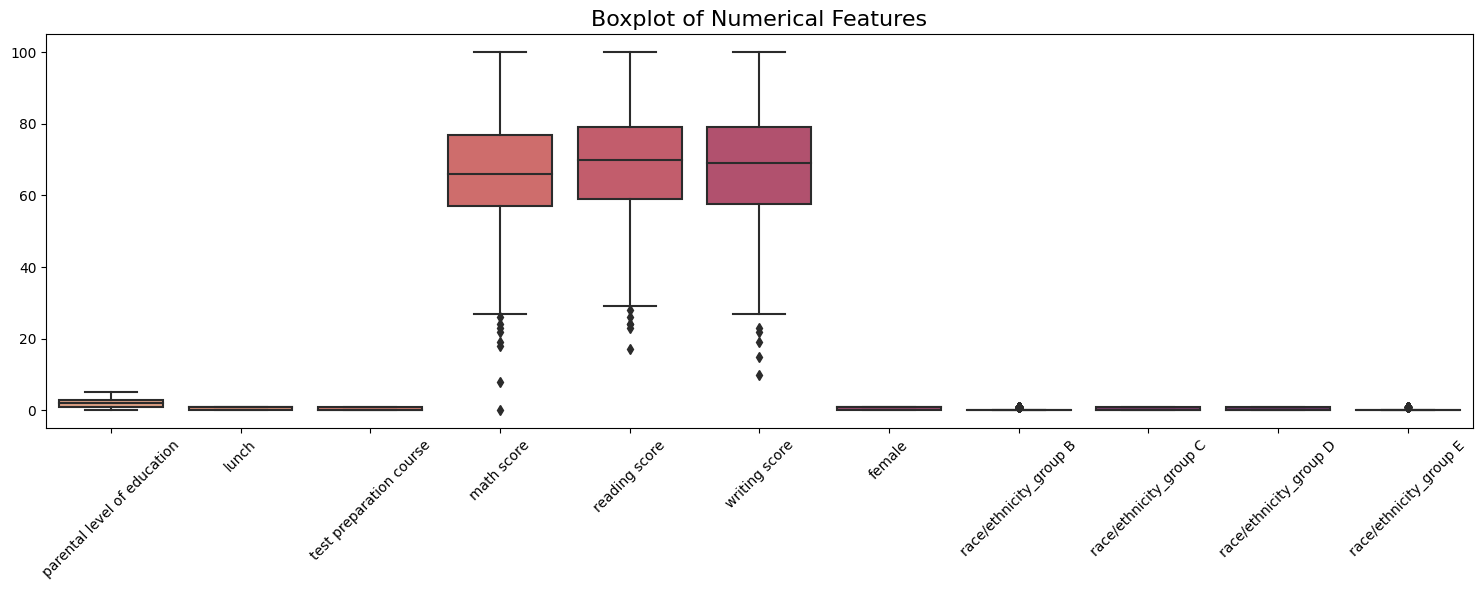

In [15]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numeric_columns], palette="flare")
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

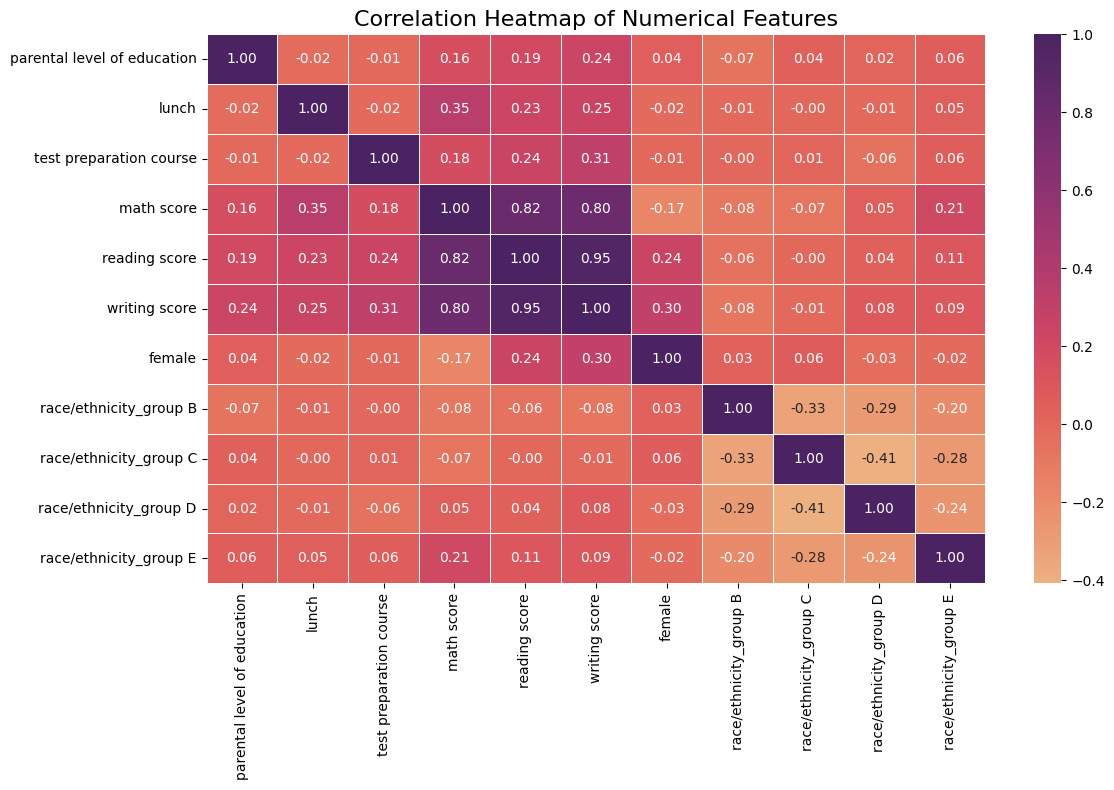

In [16]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True,cmap="flare", fmt=".2f", linewidths=0.5, linecolor="white")
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

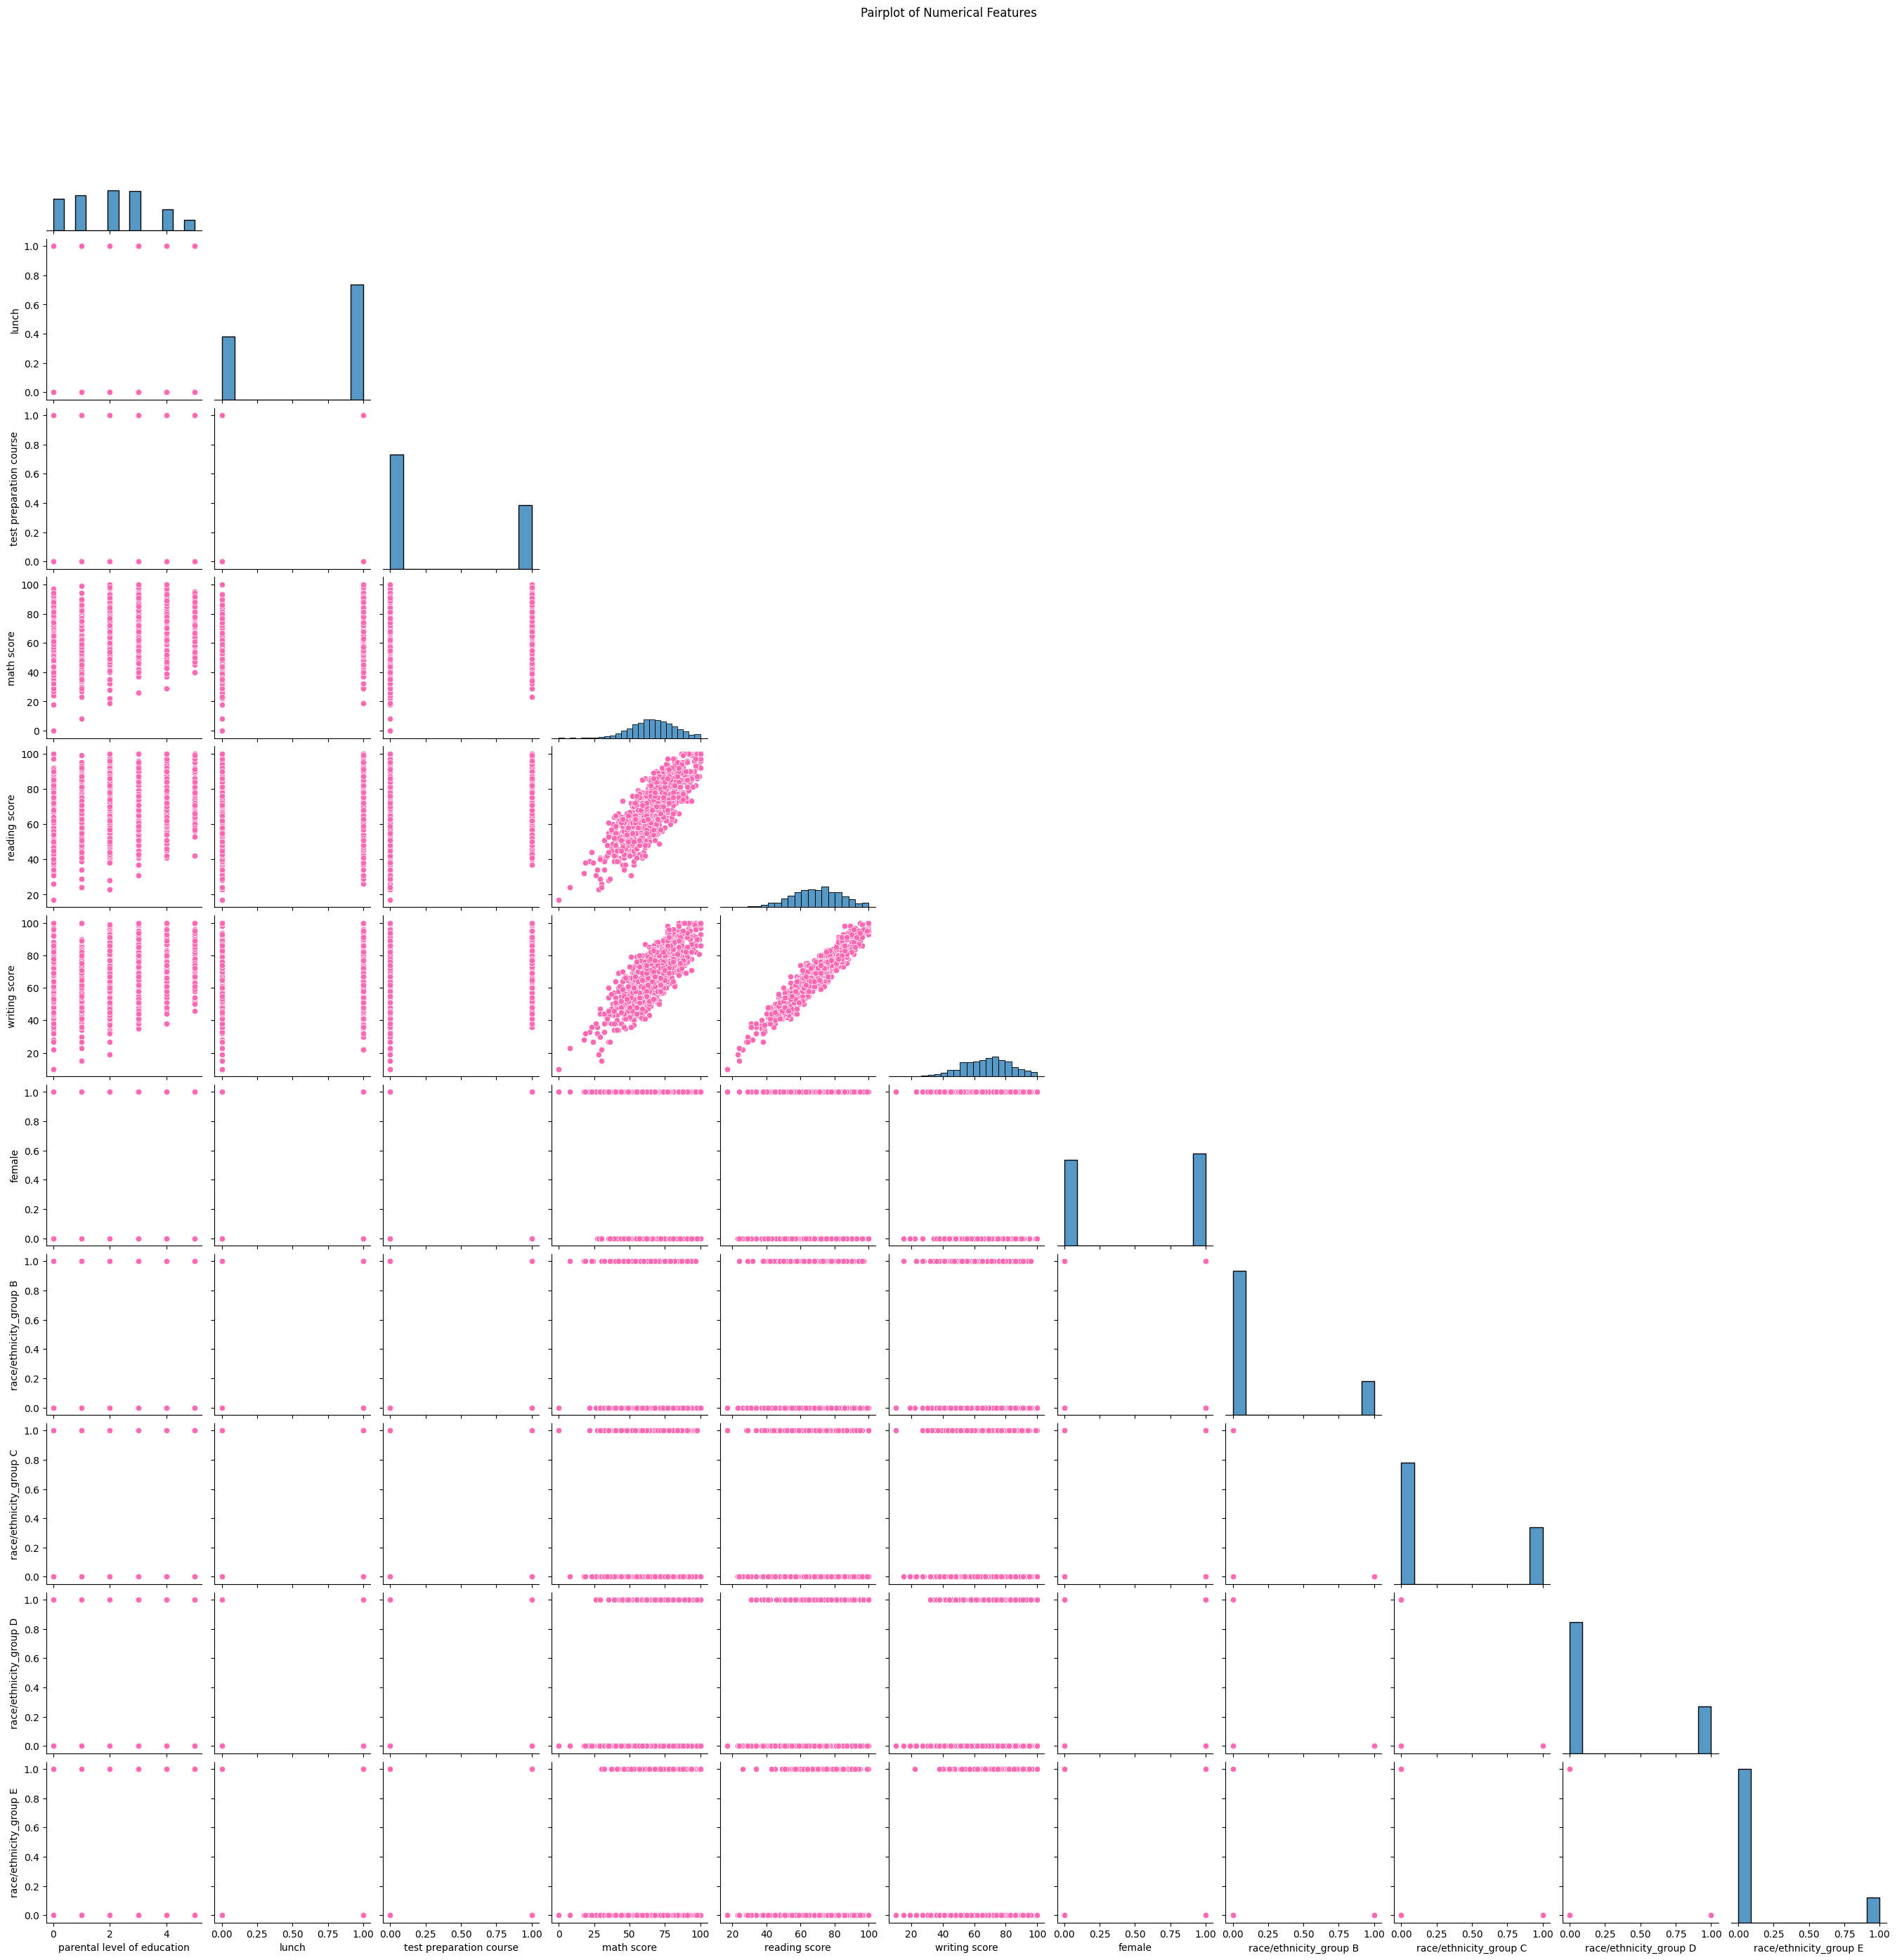

In [17]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
sns.pairplot(df[numeric_cols], corner=True, diag_kind="hist", plot_kws={"color": "#ff69b4"})
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()


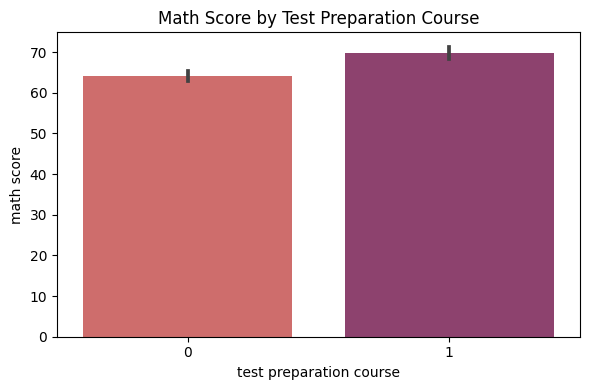

In [18]:
plt.figure(figsize=(6, 4))
sns.barplot(x="test preparation course", y="math score", data=df, palette="flare")
plt.title("Math Score by Test Preparation Course")
plt.tight_layout()
plt.show()

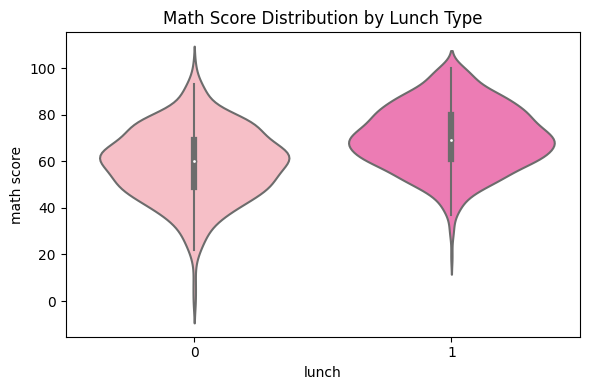

In [19]:
pink_palette = ["#ffb6c1", "#ff69b4", "#ffc0cb", "#f4a7b9", "#f7c6d9"]
plt.figure(figsize=(6, 4))
sns.violinplot(x="lunch", y="math score", data=df, palette=pink_palette)
plt.title("Math Score Distribution by Lunch Type")
plt.tight_layout()
plt.show()

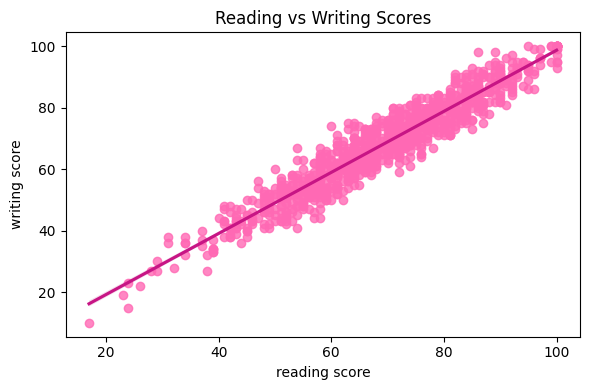

In [20]:
plt.figure(figsize=(6, 4))
sns.regplot(x="reading score", y="writing score", data=df, scatter_kws={"color": "#ff69b4"}, line_kws={"color": "#c71585"})
plt.title("Reading vs Writing Scores")
plt.tight_layout()
plt.show()

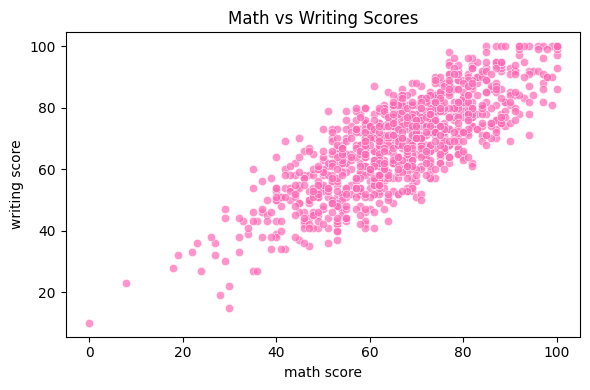

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="math score", y="writing score", data=df, color="#ff69b4", alpha=0.7)
plt.title("Math vs Writing Scores")
plt.tight_layout()
plt.show()

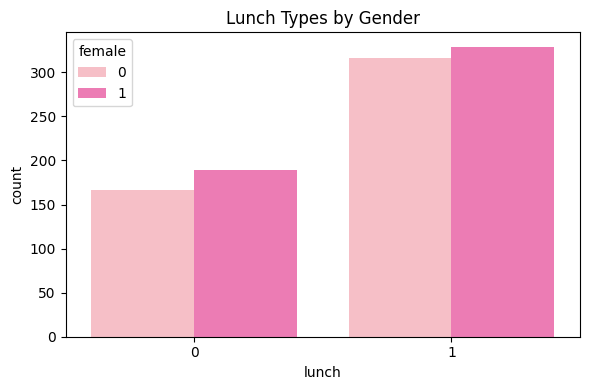

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x="lunch", hue="female", data=df, palette=pink_palette)
plt.title("Lunch Types by Gender")
plt.tight_layout()
plt.show()

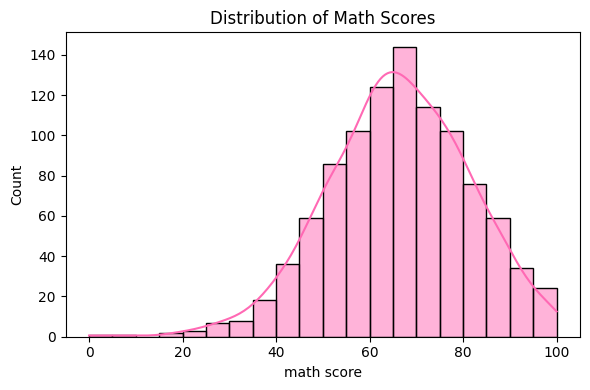

In [23]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.figure(figsize=(6, 4))
sns.histplot(df["math score"], bins=20, kde=True, color="#ff69b4")
plt.title("Distribution of Math Scores")
plt.tight_layout()
plt.show()


In [24]:
y = df["math score"]
X = df.drop("math score", axis=1)

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop("math score", axis=1)
y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(800, 10)

In [27]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    numeric_df = df.select_dtypes(include=["int64", "float64"])  # 👈 sadece sayısal verilerle çalış
    corr = numeric_df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop     

In [28]:
cols_to_drop = correlation_for_dropping(X, threshold=0.90)
X = X.drop(columns=cols_to_drop)

In [29]:
cols_to_drop

{'writing score'}

In [30]:
columns_dropping = correlation_for_dropping(X_train, threshold=0.90)

X_train.drop(columns_dropping, axis=1, inplace=True)
X_test.drop(columns_dropping, axis=1, inplace=True)

In [31]:
X_train.shape

(800, 9)

In [32]:
X_test.shape

(200, 9)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Mean Absolute Error: 4.7314137370161164
Mean Squared Error: 35.83871342963418
R2 Score: 0.8527206826804393


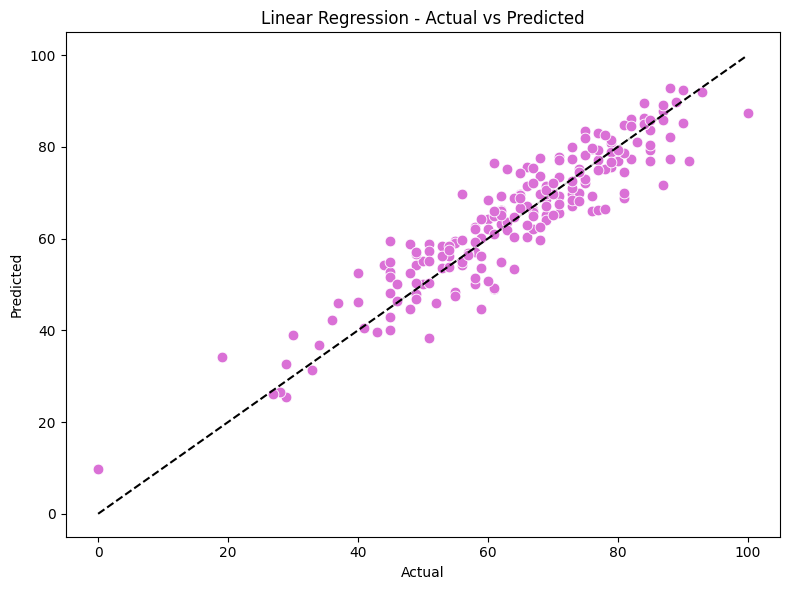

In [34]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")  # Doğru tahmin çizgisi
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()


Mean Absolute Error: 4.961433112530734
Mean Squared Error: 40.113335277153524
R2 Score: 0.8351541093507908


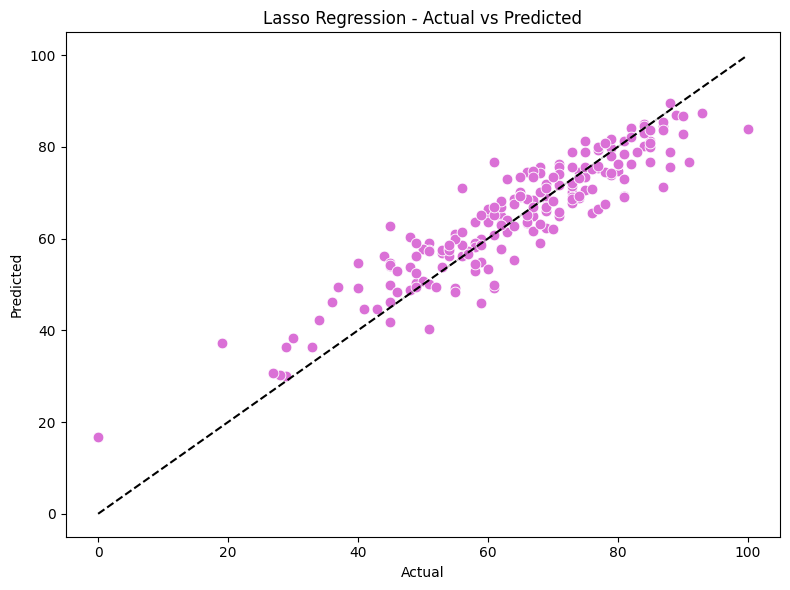

In [35]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lasso = Lasso() 
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()


Mean Absolute Error: 4.731193590805446
Mean Squared Error: 35.85849268692393
R2 Score: 0.8526393997539068


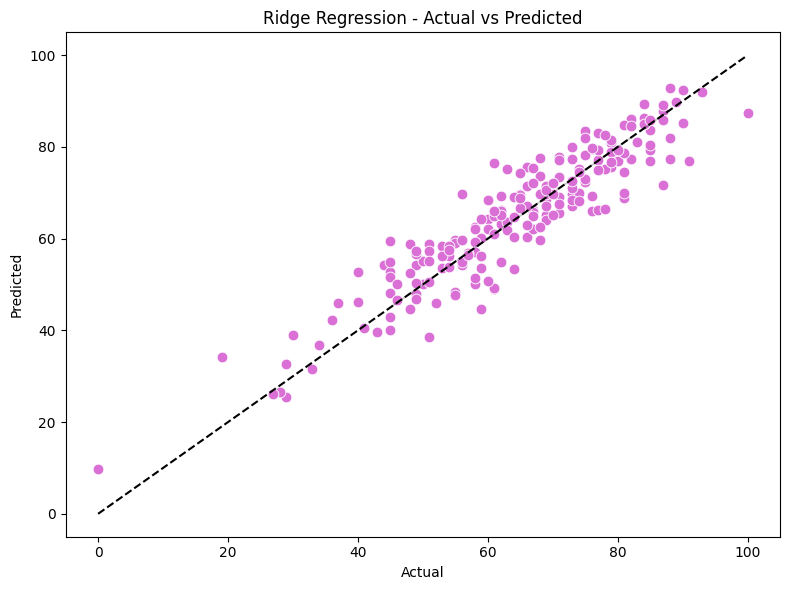

In [36]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()

Mean Absolute Error: 6.710145063073205
Mean Squared Error: 71.4138472174456
R2 Score: 0.7065245468144543


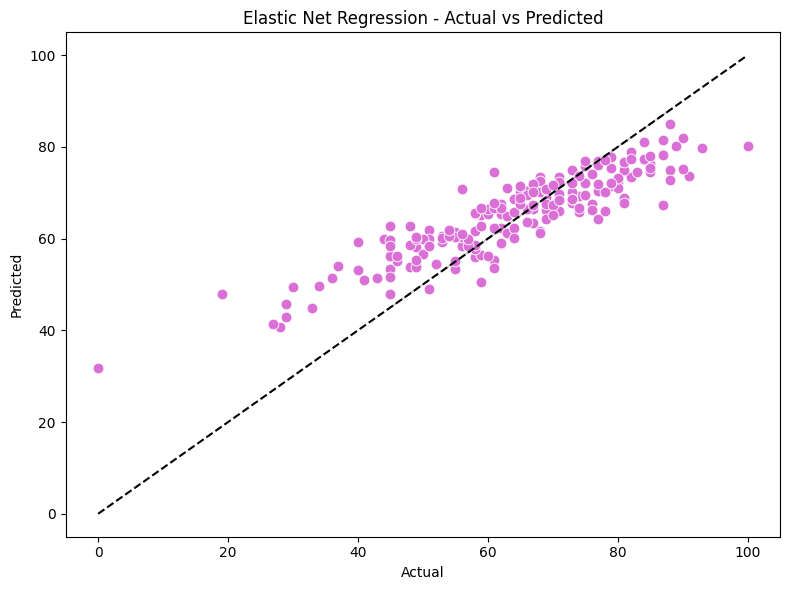

In [37]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Elastic Net Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()


Best Alpha: 0.012234454266951833
Mean Absolute Error: 4.731976311428022
Mean Squared Error: 35.87671711029541
R2 Score: 0.8525645064227618


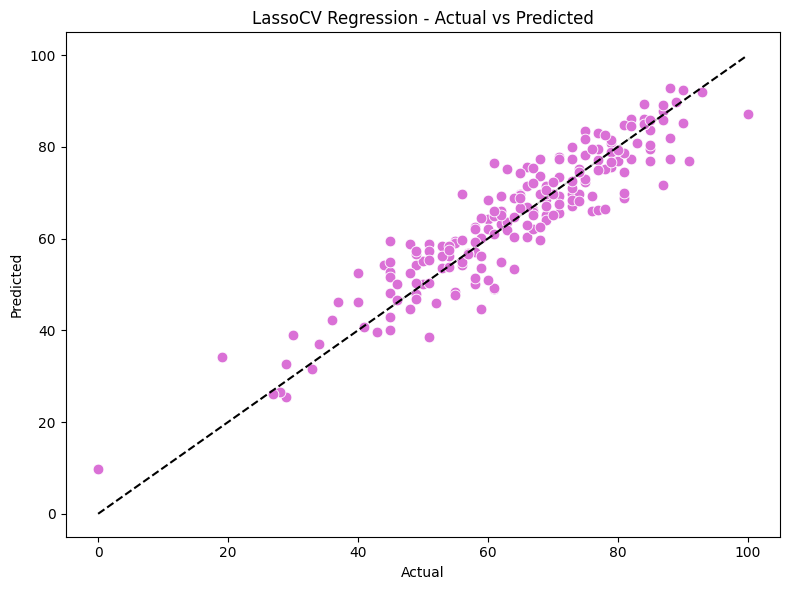

In [38]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
y_pred = lasso_cv.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Best Alpha:", lasso_cv.alpha_)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LassoCV Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()

Best Alpha: 0.1
Mean Absolute Error: 4.7313921113990896
Mean Squared Error: 35.84064828391931
R2 Score: 0.8527127313900342


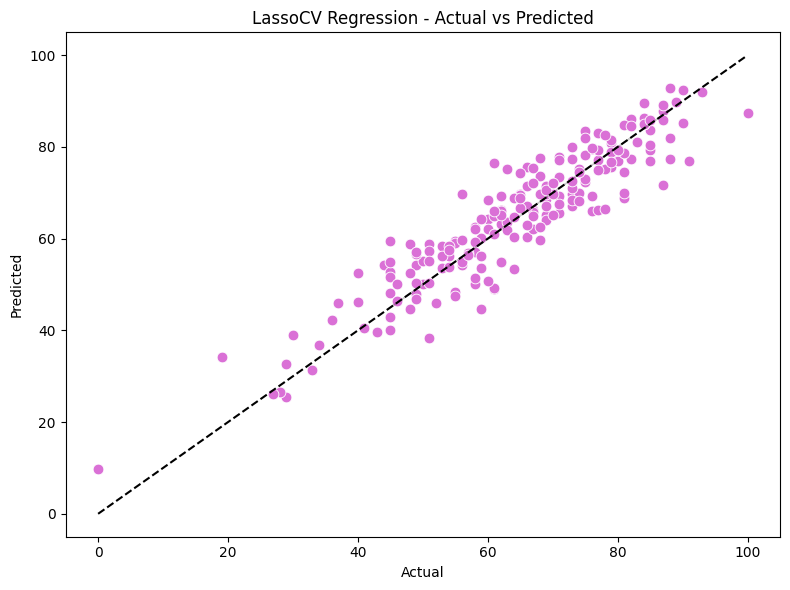

In [39]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred = ridge_cv.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Best Alpha:", ridge_cv.alpha_)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LassoCV Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()

Best Alpha: 0.01
Best L1 Ratio: 0.9
Mean Absolute Error: 4.731645443430534
Mean Squared Error: 35.88273159444837
R2 Score: 0.8525397898792448


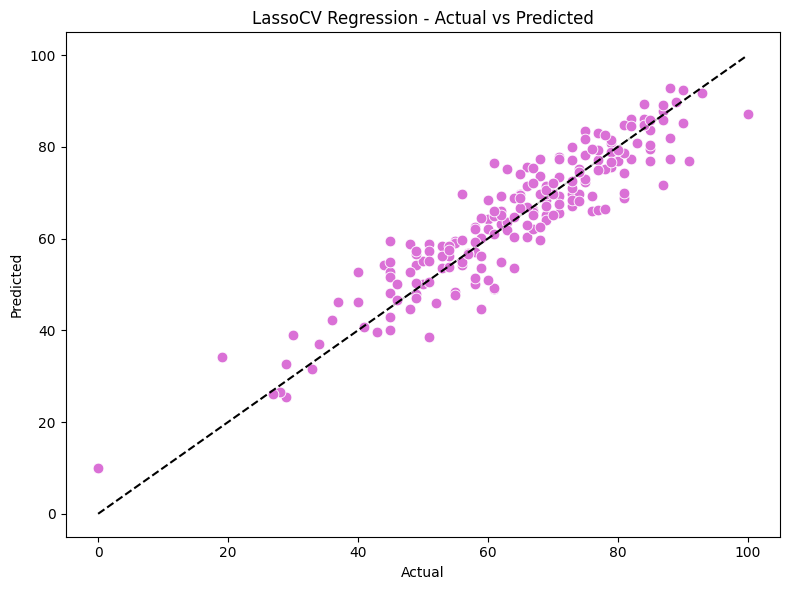

In [40]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

elastic_cv = ElasticNetCV(alphas=[0.01, 0.1, 1.0, 10.0], l1_ratio=[0.1, 0.5, 0.9], cv=5)
elastic_cv.fit(X_train_scaled, y_train)
y_pred = elastic_cv.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Best Alpha:", elastic_cv.alpha_)
print("Best L1 Ratio:", elastic_cv.l1_ratio_)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", score)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="orchid", s=60)
sns.lineplot(x=y_test, y=y_test, color="black", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LassoCV Regression - Actual vs Predicted")
plt.tight_layout()
plt.show()

In [41]:
linear_mse = mean_squared_error(y_test, linear.predict(X_test_scaled))
linear_r2 = r2_score(y_test, linear.predict(X_test_scaled))

lasso_mse = mean_squared_error(y_test, lasso_cv.predict(X_test_scaled))
lasso_r2 = r2_score(y_test, lasso_cv.predict(X_test_scaled))

ridge_mse = mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))
ridge_r2 = r2_score(y_test, ridge_cv.predict(X_test_scaled))

elastic_mse = mean_squared_error(y_test, elastic_cv.predict(X_test_scaled))
elastic_r2 = r2_score(y_test, elastic_cv.predict(X_test_scaled))

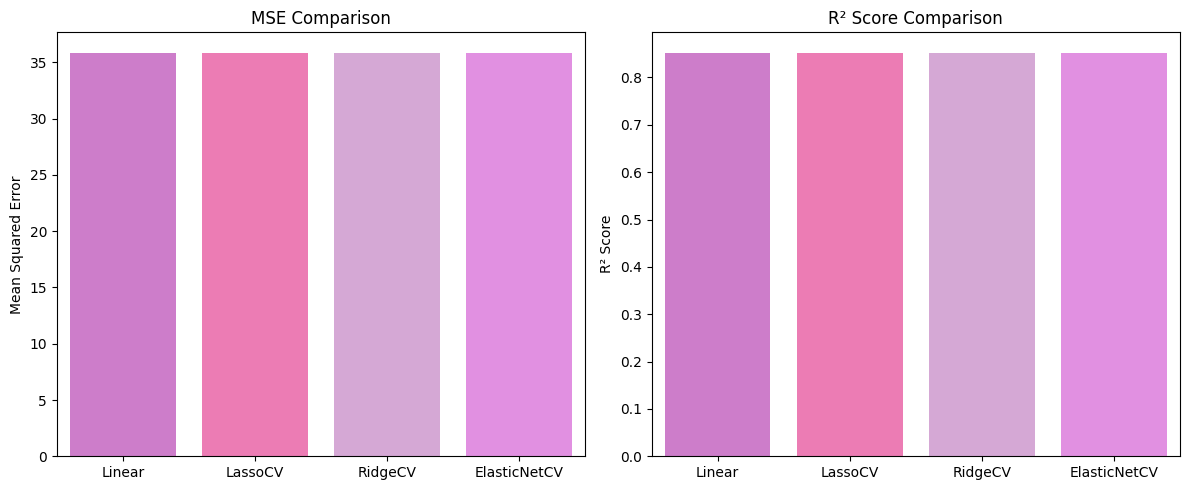

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Linear", "LassoCV", "RidgeCV", "ElasticNetCV"]
mse_scores = [linear_mse, lasso_mse, ridge_mse, elastic_mse]
r2_scores = [linear_r2, lasso_r2, ridge_r2, elastic_r2]
colors = ["orchid", "hotpink", "plum", "violet"]

plt.figure(figsize=(12, 5))

# MSE Barplot
plt.subplot(1, 2, 1)
sns.barplot(x=models, y=mse_scores, palette=colors)
plt.title("MSE Comparison")
plt.ylabel("Mean Squared Error")

# R² Score Barplot
plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_scores, palette=colors)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()